<a href="https://colab.research.google.com/github/mir-abir-hossain/SOTA-paper-implementation/blob/main/Transformer-Attention-Is-All-You-Need/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

```
# Welcome to this tiny tutorial of PyTorch implementation of the paper "Attention is all you Need"
# It's always better to try the code yourself and try to understand how things are happening.
# Taking help of chatgpt, gemini etc is very good, in parts where you don't understand
# I tried to implemented this using all raw PyTorch code
# There are high level functions and modules by which you can initiate transformer blocks in just one line of code
# This tutorial is for learning purpose
```


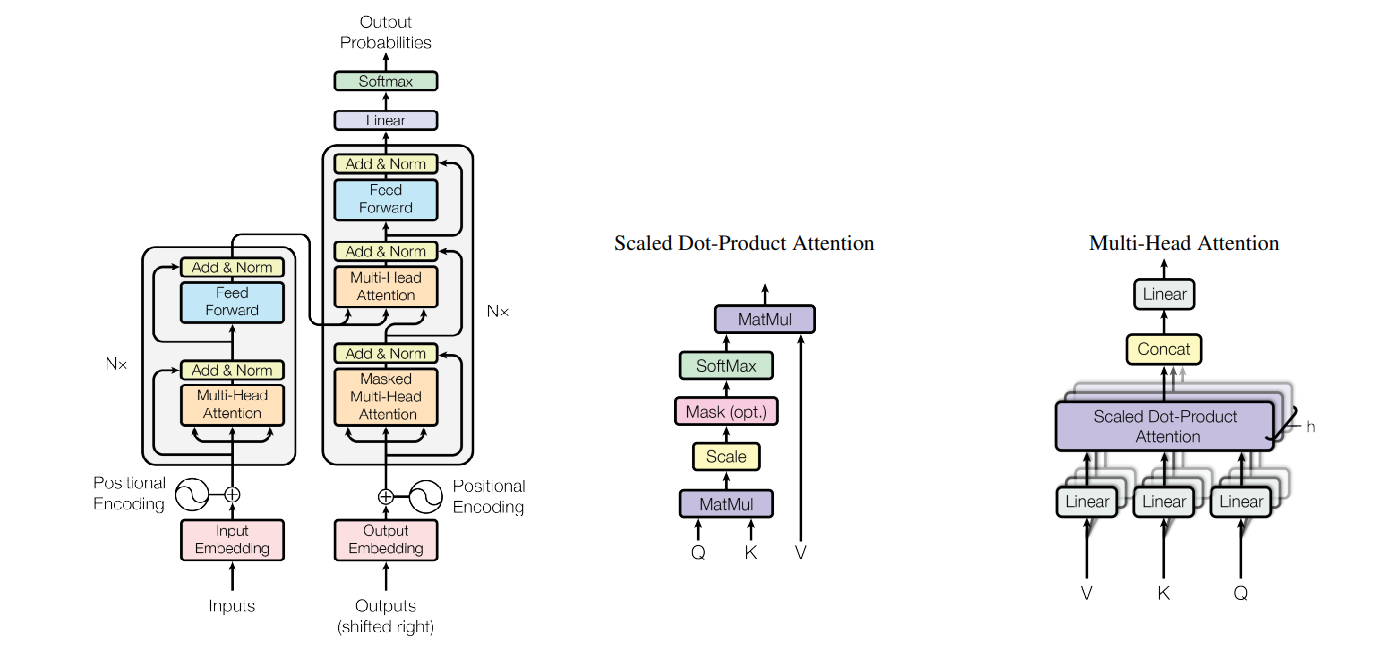

In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import math

```
### First lets build the self-attention
### A good example is given in the documentation in this page https://docs.pytorch.org/tutorials/intermediate/transformer_building_blocks.html
```

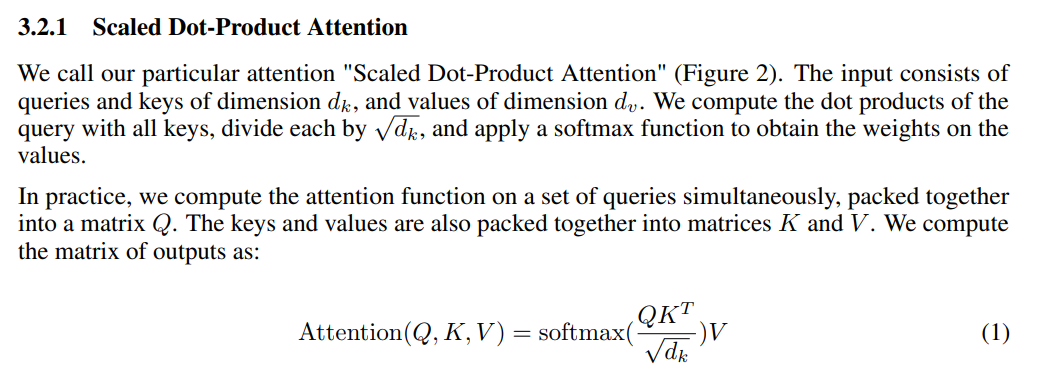

In [83]:
class Self_Attention(nn.Module):

    def __init__(self, dmodel=512, dk=512):
        super().__init__()
        self.dmodel, self.dk = dmodel, dk
        self.query_weight = nn.Linear(self.dmodel, self.dk) # [B, 512, 512]
        self.key_weight = nn.Linear(self.dmodel, self.dk) # [B, 512, 512]
        self.value_weight = nn.Linear(self.dmodel, self.dk) # [B, 512, 512]

    def forward(self, x):
        query = self.query_weight(x) # [B,  word_count, 512]
        key= self.key_weight(x) # [B, word_count, 512]
        value = self.value_weight(x) # [B, word_count, 512]

        attention_score = torch.matmul(query, key.transpose(-1, -2)) # [B , word_count, word_count]
        attention_score = attention_score / (self.dk ** 0.5)
        attention_score = F.softmax(attention_score, -1)
        attention_score = torch.matmul(attention_score, value) # [B, word_count, 512]
        return attention_score


```
Okay! Lets try to understand the code and how the formula is working!
    step 1: We take the input layer which is a batch of sentences broke down to embedding
            Example: One batch might have the following 3 sentences ->
            a. He is eating rice
            b. We are playing football
            c. Have they left yet
        Each word is embedded to 512 size vector. So "He" is a token that looks like
        [0.24, 0.56, ........] (length of 512)
        So if we count, with all the embeddings we get the batch with a shape of ->
            [3, 4, 512]
            3 -> 3 sentence
            4 -> 4 word
            512 -> each word of 512 length vector

    step 2: We define 3 weight metrics Wq, Wk and Wv. They are initialized randomly and will
        be trained along the way. Their dimensions are :
            [512, 512]
        They are multiplied with inputs and gives us Q, K and V respectively.
        The dimensions after multiplying is calculated below ->
            [3, 4, 512] @ [512, 512] ->
            [[4, 512] @ [512, 512],
             [4, 512] @ [512, 512]
             [4, 512] @ [512, 512]] ->
            [[4, 512], [4, 512], [4, 512]] ->
            [3, 4, 512]
    step 3: Now we do the attention score mechanism using the formula in from the paper
        First doing a matrix multiplication between query and transpose of key
            [3, 4, 512] @ [3, 4, 512].T ->
            [[4, 512] @ [512, 4],
             [4, 512] @ [512, 4]
             [4, 512] @ [512, 4]] ->
            [3, 4, 4]
        So we get a 4 * 4 table which basically represents the relationships of the words with each other
        from each sentence
        Lastly we divide it with square root of dk for scaling purpose (also helps with the exploding problem)
        Then we do the softmax in the last dimension in this way ->
        Now we have 4 * 4 table for one sentence. So for example first row is like this ->
            O | He    | is     | eating | rice |
            He| 0.457 | -0.324 | 0.55   | 0.35 |
        After applying softmax, the summation of all will be 1
            O | He    | is     | eating | rice |
            He| 0.32  | 0.06   | 0.38   | 0.24 |
        So we can tell He is attenting to "He" 32%, "is" 6% etc etc
    step 4: Now we multiply the result with value ->
        [3, 4, 4] @ [3, 4, 512] ->
        [[4, 4] @ [4, 512],
         [4, 4] @ [4, 512]
         [4, 4] @ [4, 512]] ->
        [3, 4, 512]
    And that is the output format of our self attention task
```

```
### Great! Now let's move onto applying the MultiHead Attention part
```

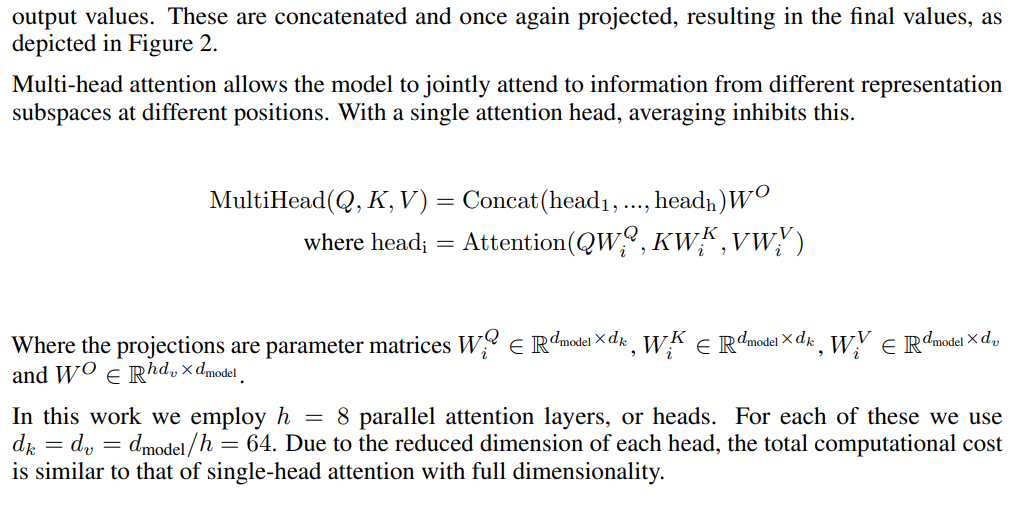

In [114]:
class MultiheadAttention(nn.Module):

    def __init__(self, head=8, embed_dim=512, masked=False):
        super().__init__()
        self.masked = masked
        self.head = head
        self.embed_dim = embed_dim
        self.each_embed_dim = int(self.embed_dim/self.head)
        self.attention_heads = nn.ModuleList([Self_Attention(dk=self.each_embed_dim, masked=self.masked) for _ in range(head)])
        self.weight = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):
        processed_chunks = {}
        for h in range(self.head):
            chunk_attention_block = self.attention_heads[h]
            processed_chunks[f"chunk_{h}"] = chunk_attention_block(x)

        x = torch.concat(tuple(processed_chunks.values()), dim=-1)
        x = self.weight(x)
        print(x.shape)
        return x


```
    In the multihead attention, we are doing almost the same thing as self attention,
    but slightly differently.
    step 1: Instead of applying self attention for the whole thing, we are diving it in multiple heads
            [3, 4, 512] -> 8 * [3, 4, 64]
        so, instead of having one thing to process, we are processing 8 things.
    step 2: Applying the self attention and get output
            8 * [3, 4, 64]
    step 3: Now we concat all the 8 output in the last dimension to get back the full thing.
            [3, 4, 64] + [3, 4, 64] + ....... + [3, 4, 64] = [3, 4, 512]
    step 4: Lastly we multiply the output with a weight metrics that we will learn along the way
            [3, 4, 512] @ [512, 512] ->
            [[4, 512] @ [512, 512],
             [4, 512] @ [512, 512]
             [4, 512] @ [512, 512]] ->
            [3, 4, 512]
        And that's the end of MultiHead Attention step
```

```
### Great! Now lets build the feedforward network. This is kind of straightforward if you already good at neural networks
```

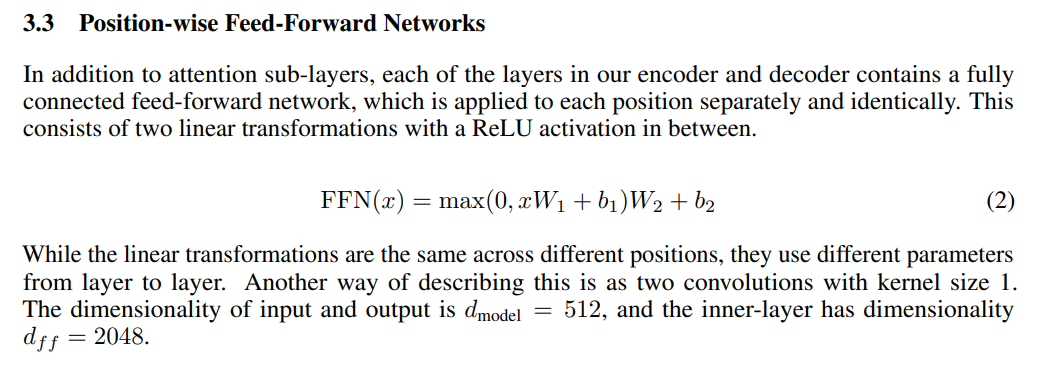

In [103]:
class FeedForwardNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(512, 2048),
            nn.ReLU(),
            nn.Linear(2048, 512)
        )

    def forward(self, x):
        x = self.linear_relu_stack(x)
        return x


In [112]:
class Self_Attention(nn.Module):

    def __init__(self, dmodel=512, dk=512, masked=False):
        super().__init__()
        self.dmodel, self.dk = dmodel, dk
        self.masked = masked
        self.query_weight = nn.Linear(self.dmodel, self.dk) # [B, 512, 512]
        self.key_weight = nn.Linear(self.dmodel, self.dk) # [B, 512, 512]
        self.value_weight = nn.Linear(self.dmodel, self.dk) # [B, 512, 512]

    def forward(self, x):
        query = self.query_weight(x) # [B,  word_count, 512]
        key= self.key_weight(x) # [B, word_count, 512]
        value = self.value_weight(x) # [B, word_count, 512]

        attention_score = torch.matmul(query, key.transpose(-1, -2)) # [B , word_count, word_count]
        attention_score = attention_score / (self.dk ** 0.5)
        if self.masked==True:
            sentence_length = x.size(-2)
            mask = torch.ones((sentence_length, sentence_length))
            attention_score = attention_score.masked_fill(mask, -1e9)

        attention_score = F.softmax(attention_score, -1)
        attention_score = torch.matmul(attention_score, value) # [B, word_count, 512]
        return attention_score

```
### So, we have updated the masked attention.
### We can just call it with masked=True and it will work as maskedmultiheadattention.
```

```
### The basic feedforward network is ready.
### Self Attention and MultiHead attention is also ready.
### Lets now compile these three together and add residual and layernorm to complete the encoder block
```

In [107]:
class DecoderBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.multihead_attention_block = MultiheadAttention()
        self.masked_multihead_attention_block = MultiheadAttention(masked=True)
        self.feedforward = FeedForwardNetwork()
        self.layernorm = nn.LayerNorm(512)

    def forward(self, x):
        attention_val = self.multihead_attention_block(x)
        x = x + attention_val
        x = self.layernorm(x)
        feed_val = self.feedforward(x)
        x = x + feed_val
        x = self.layernorm(x)
        return x

In [100]:
# now lets think of a word that has embedding vector size of 512
# Lets think of it as input and utilize the feedforward network to see the output shapes
word_embed = torch.randn(1, 2, 512)

# Ok now give this as input in the feed forward network to run a forward pass
one_feedforward_network = FeedForwardNetwork()
one_forward_pass = one_feedforward_network(word_embed)

In [101]:
one_forward_pass.shape

torch.Size([1, 2, 512])

In [79]:
one_feedforward_network

FeedForwardNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=512, out_features=2048, bias=True)
    (1): ReLU()
    (2): Linear(in_features=2048, out_features=512, bias=True)
  )
)

In [73]:
one_forward_pass.shape

torch.Size([1, 512])

In [6]:
# Great! So we have successfully pass the input through the feed forward network
# We can see the one_forward_pass.shape is [1, 512], which exactly what we wanted
# as the out_feature of the feedforward network should be 512

```
### Okay that's the easiest part. phew! 😅
### Just the basic block of feed forward is ready
### Remember later we have to do the layer normalization and residual adding.
### But we will do that later for better understanding
### Now lets get started with the multihead attention
### First lets build the self-attention
### A good example is given in the documentation in this page https://docs.pytorch.org/tutorials/intermediate/transformer_building_blocks.html
```

In [82]:
basic_attention_block = Self_Attention()
one_pass_in_attention = basic_attention_block(word_embed)
one_pass_in_attention.shape

x torch.Size([1, 2, 512])
q torch.Size([1, 2, 512])
v torch.Size([1, 2, 512])
f torch.Size([1, 2, 2])
l torch.Size([1, 2, 512])


torch.Size([1, 2, 512])

```
# Great! We got the self attention block
# Now lets move on to the multihead attention block
# It's basically the same thing, just with a specific technicality
# That is we will divide the full dimension in of the input embedding
# into chunks and calculate attention and at last
# we concatanate the attentions
# For the original paper they have divided into 8 chunks, we will do that
```


```
### Okay first I will prepare the feed forward network from the transformer block, that's the easiest part if you know how mlp works
### Taking the help from here from the documentation https://docs.pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html
```

In [89]:
multihead = MultiheadAttention()
fff = multihead(torch.randn(3, 4, 512))
print(fff.shape)

torch.Size([3, 4, 512])
torch.Size([3, 4, 512])


In [ ]:
ff = torch.randn(1, 512)
total = ff.size(-1)
part = total/8
print(part)
location = []
chunks = {}
for i in range(8):
    location.append((part*i, part*(i+1)))
    chunks[f"ffx_{i}"] = ff[:, int(part*i):int(part*(i+1))]
    print(chunks[f"ffx_{i}"].shape)

64.0
torch.Size([1, 64])
torch.Size([1, 64])
torch.Size([1, 64])
torch.Size([1, 64])
torch.Size([1, 64])
torch.Size([1, 64])
torch.Size([1, 64])
torch.Size([1, 64])


In [ ]:
chunks['ffx_0'].shape, chunks['ffx_1'].shape,


(torch.Size([1, 64]), torch.Size([1, 64]))

In [ ]:
torch.concat((chunks['ffx_0'], chunks['ffx_1']), dim=-1).shape

torch.Size([1, 128])

In [ ]:
asd = nn.Linear(64, 512)
xx = torch.randn(1, 64)

In [ ]:
asd(xx).shape

torch.Size([1, 512])

In [25]:
batch_of_sentence = torch.randn(3, 4, 16)

In [26]:
w_q = nn.Linear(16, 2)
w_k = nn.Linear(16, 2)
w_v = nn.Linear(16, 2)

In [27]:
query = w_q(batch_of_sentence)
key = w_k(batch_of_sentence)
value = w_v(batch_of_sentence)

In [28]:
query.shape, key.shape, value.shape

(torch.Size([3, 4, 2]), torch.Size([3, 4, 2]), torch.Size([3, 4, 2]))

In [29]:
query[0, 0], key[0, 0]

(tensor([-0.3897,  0.0482], grad_fn=<SelectBackward0>),
 tensor([-0.8065, -0.1596], grad_fn=<SelectBackward0>))

In [36]:
query[0, 0] @ key[0, 1].T

tensor(0.1107, grad_fn=<DotBackward0>)

In [52]:
tempp = torch.matmul(query, key.transpose(-1, -2))

In [34]:
tempp.shape

torch.Size([3, 4, 4])

In [37]:
tempp[0, 0, 1]

tensor(0.1107, grad_fn=<SelectBackward0>)

In [53]:
tempp = tempp / (2 ** 0.5)
print(tempp)
softmax_return = F.softmax(tempp, dim=2)
print(softmax_return)
softmax_return.sum(dim=2)

tensor([[[ 0.2168,  0.0782,  0.0853,  0.2162],
         [-0.1518, -0.0629, -0.0503, -0.1472],
         [-0.1066,  0.0866, -0.1866, -0.1697],
         [ 0.1518, -0.0355,  0.1641,  0.1971]],

        [[ 0.4229,  0.1733,  0.5363,  0.0731],
         [ 0.2567,  0.2778,  0.4235, -0.0061],
         [-0.0973, -0.0543, -0.1315, -0.0126],
         [ 0.5115, -0.4249,  0.2882,  0.2740]],

        [[-0.1290, -0.4713,  0.2870, -0.0310],
         [ 0.0379,  0.2339, -0.1036,  0.0239],
         [ 0.0085, -0.2218,  0.0324, -0.0371],
         [-0.5386,  0.1835,  0.7624,  0.2033]]], grad_fn=<DivBackward0>)
tensor([[[0.2669, 0.2324, 0.2340, 0.2667],
         [0.2378, 0.2599, 0.2633, 0.2389],
         [0.2454, 0.2977, 0.2265, 0.2304],
         [0.2572, 0.2133, 0.2604, 0.2691]],

        [[0.2775, 0.2162, 0.3108, 0.1956],
         [0.2518, 0.2572, 0.2975, 0.1936],
         [0.2440, 0.2547, 0.2358, 0.2655],
         [0.3355, 0.1315, 0.2684, 0.2646]],

        [[0.2310, 0.1640, 0.3502, 0.2548],
         [0.245

tensor([[1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000]], grad_fn=<SumBackward1>)

In [55]:
softmax_return.shape

torch.Size([3, 4, 4])

In [60]:
attention_score = torch.matmul(softmax_return, value)

In [61]:
attention_score.shape

torch.Size([3, 4, 2])

In [111]:
F.softmax(torch.triu(torch.randn(4, 4)), dim=-1)

tensor([[0.0577, 0.0655, 0.7008, 0.1760],
        [0.4223, 0.1163, 0.1345, 0.3269],
        [0.2769, 0.2769, 0.3060, 0.1402],
        [0.1583, 0.1583, 0.1583, 0.5250]])